In [1]:
%run -i ./02_marginalization_bayes_rule_inference.ipynb
%matplotlib widget
np.set_printoptions(precision=3, suppress=True)

The *expectation operator*, $E[\cdot]$, is an important tool when working with probabilities. It allows us to work out the 'average' value of a function of a random variable, $f(\mathbf{x})$, and is defined as

$$E[f(\mathbf{x})] = \int f(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.13}$$

where $p(\mathbf{x})$ is the PDF for the random variable, $\mathbf{x}$, and the integration is assumed to be over the domain of $\mathbf{x}$. This is sometimes referred to as the *law of the unconscious statistician (LOTUS)*.

In [2]:
def _expectation(fx, px, bounds=None, n=None):
  return _integrate(f=(lambda x: fx(x) * px(x)), bounds=bounds, n=n)

In [3]:
if __name__ == '__main__' and '__file__' not in globals():
  print(_expectation(lambda x: x, 
                     lambda x: _gaussian(5.0, 10.0)(x), 
                     [(-256.0, 256.0)],
                     256))

4.999999999999999


For a general matrix function, $\mathbf{F}(\mathbf{x})$, the expectation is written as

$$E[\mathbf{F}(\mathbf{x})] = \int \mathbf{F}(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.14}$$

but note that we must interpret this as

$$E[\mathbf{F}(\mathbf{x})] = \big[E[f_{ij}(\mathbf{x})]\big] = \left[\int f_{ij}(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}\right]. \tag{2.15}$$

In [4]:
def __expectation(fX, pX, bounds=None, n=None):
  return _integrate(lambda *X: fX(*X) * pX(*X), bounds)

def _expectation(FX, pX, bounds=None, n=None):
  if callable(FX):
    return __expectation(FX, pX, bounds, n)
  return np.array([_expectation(fX, pX, bounds, n) for fX in FX])

In [5]:
import pprint

if __name__ == '__main__' and '__file__' not in globals():
  Fx = [[lambda x: x ** 0, lambda x: x ** 1],
        [lambda x: x ** 2, lambda x: x ** 3],
        [lambda x: x ** 4, lambda x: x ** 5]]
  px = _gaussian(3.0, 2.0)
  
  pprint.pprint(_expectation(Fx, px, [(-16, 16)]))

array([[   1.,    3.],
       [  13.,   63.],
       [ 345., 2043.]])


In [6]:
if __name__ == '__main__' and '__file__' not in globals():
  FX = [[lambda *X: X[0] ** 0 + X[1] ** 1, lambda *X: X[0] ** 1 + X[1] ** 2],
        [lambda *X: X[0] ** 2 + X[1] ** 3, lambda *X: X[0] ** 3 + X[1] ** 4],
        [lambda *X: X[0] ** 4 + X[1] ** 5, lambda *X: X[0] ** 5 + X[1] ** 6]]
  pX = lambda *X: _gaussian(-2.0, 2.0)(X[0]) * _gaussian(0.0, 1.0)(X[1])

  pprint.pprint([[f(1, 2) for f in row] for row in FX])
  pprint.pprint(_expectation(FX, pX, [(-16, 16), (-16, 16)]))

[[3, 5], [9, 17], [33, 65]]
array([[   1.,   -1.],
       [   8.,  -29.],
       [ 160., -817.]])


When working with mass distributions (a.k.a., density functions) in classical mechanics, we often keep track of only a few properties called the *moments* of mass (e.g., mass, center of mass, inertia matrix). The same is true with PDFs. The zeroth probability moment is always $1$ since this is exactly the axiom of total probability. The first probability moment is known as the *mean*, $\boldsymbol{\mu}$:

$$\boldsymbol{\mu} = E[\mathbf{x}] = \int \mathbf{x}\,p(\mathbf{x})\,d\mathbf{x}. \tag{2.16}$$

In [7]:
def _mean(pX, bounds):
  identity = [lambda *X, i=i: X[i] for i in range(len(bounds))]
  return _expectation(identity, pX, bounds)

In [8]:
if __name__ == '__main__' and '__file__' not in globals():
  FX = [[lambda *X: X[0] ** 0 + X[1] ** 1, lambda *X: X[0] ** 1 + X[1] ** 2],
        [lambda *X: X[0] ** 2 + X[1] ** 3, lambda *X: X[0] ** 3 + X[1] ** 4],
        [lambda *X: X[0] ** 4 + X[1] ** 5, lambda *X: X[0] ** 5 + X[1] ** 6]]
  pX = lambda *X: _gaussian(-2.0, 2.0)(X[0]) * _gaussian(0.0, 1.0)(X[1])

  pprint.pprint(_mean(pX, [(-16, 16), (-16, 16)]))

array([-2.,  0.])


The second probability moment is known as the *covariance matrix*, $\boldsymbol{\Sigma}$:

$$\boldsymbol{\Sigma} = E\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T\right]. \tag{2.17}$$

In [11]:
def _covariance_matrix(pX, bounds=None, n=None):
  mu = _mean(pX, bounds)
  foo = [[lambda *X, i=i, j=j: (X[i] - mu[i]) * (X[j] - mu[j])
          for j in range(len(bounds))]
          for i in range(len(bounds))]
  return _expectation(foo, pX, bounds)

In [13]:
if __name__ == '__main__' and '__file__' not in globals():
  FX = [[lambda *X: X[0] ** 0 + X[1] ** 1, lambda *X: X[0] ** 1 + X[1] ** 2],
        [lambda *X: X[0] ** 2 + X[1] ** 3, lambda *X: X[0] ** 3 + X[1] ** 4],
        [lambda *X: X[0] ** 4 + X[1] ** 5, lambda *X: X[0] ** 5 + X[1] ** 6]]
  pX = lambda *X: _gaussian(-2.0, 2.0)(X[0]) * _gaussian(0.0, 1.0)(X[1])

  pprint.pprint(_expectation(FX, pX, [(-16, 16), (-16, 16)]))
  X_covariance_matrix = _covariance_matrix(pX, [(-16, 16), (-16, 16)])
  pprint.pprint(X_covariance_matrix)

array([[   1.,   -1.],
       [   8.,  -29.],
       [ 160., -817.]])
array([[4., 0.],
       [0., 1.]])


Finally, we are sometimes interested in the *covariance*, $\text{cov}(\cdot, \cdot)$, of two jointly distributed variables, $\mathbf{x}$ and $\mathbf{y}$, which we denote

$$\text{cov}(\mathbf{x}, \mathbf{y}) = E\left[(\mathbf{x} - E[\mathbf{x}])\,(\mathbf{y} - E[\mathbf{y}])^T\right] = E[\mathbf{x}\mathbf{y}^T] - E[\mathbf{x}]\,E[\mathbf{y}]^T. \tag{2.18}$$

Here the expectations are taken over $p(\mathbf{x}, \mathbf{y})$, the joint density. The covariance matrix just described is then a special case, $\boldsymbol{\Sigma} = \text{cov}(\mathbf{x}, \mathbf{x})$, or sometimes simply $\boldsymbol{\Sigma} = \text{cov}(\mathbf{x})$.

In [50]:
def _discrete_covariance(x, y):
  x = np.asarray(x, float)
  if x.ndim == 1: x = x[:, None]
  y = np.asarray(y, float)
  if y.ndim == 1: y = y[:, None]
  assert x.shape[0] == y.shape[0], "x and y size is not the same"

  xc = x - x.mean(axis=0)
  yc = y - y.mean(axis=0)

  return (xc.T @ yc / x.shape[0])

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  pX = _gaussian(0.0, 2.0)
  X = [pX(i) for i in range(-16, 16)]
  print(f'X: {X}')

  pY = _gaussian(2.0, 5.0)
  Y = [pY(i) for i in range(-16, 16)]
  print(f'Y: {Y}')

  covXY = _discrete_covariance(X, Y)
  print(covXY)

X: [np.float64(2.5261355417684464e-15), np.float64(1.2171602665145048e-13), np.float64(4.567360204182297e-12), np.float64(1.334778307381426e-10), np.float64(3.037941424911643e-09), np.float64(5.384880021271638e-08), np.float64(7.433597573671488e-07), np.float64(7.991870553452737e-06), np.float64(6.691511288244268e-05), np.float64(0.0004363413475228801), np.float64(0.0022159242059690038), np.float64(0.00876415024678427), np.float64(0.02699548325659403), np.float64(0.06475879783294587), np.float64(0.12098536225957168), np.float64(0.17603266338214976), np.float64(0.19947114020071635), np.float64(0.17603266338214976), np.float64(0.12098536225957168), np.float64(0.06475879783294587), np.float64(0.02699548325659403), np.float64(0.00876415024678427), np.float64(0.0022159242059690038), np.float64(0.0004363413475228801), np.float64(6.691511288244268e-05), np.float64(7.991870553452737e-06), np.float64(7.433597573671488e-07), np.float64(5.384880021271638e-08), np.float64(3.037941424911643e-09), n

<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>

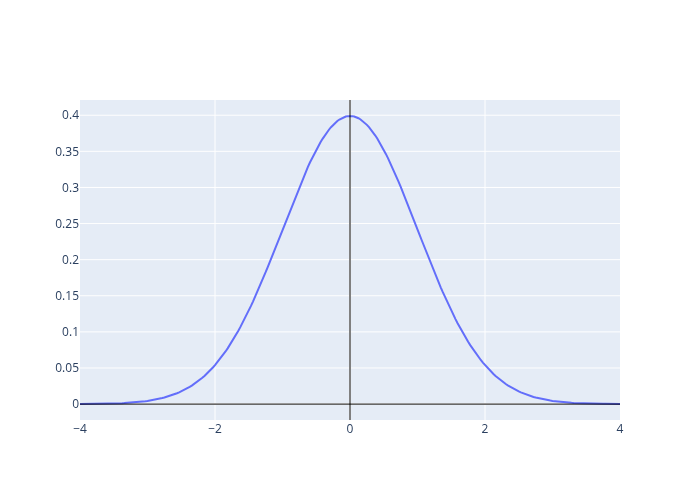

In [11]:
if __name__ == '__main__' and '__file__' not in globals():
  location = _gaussian(0.0, 1.0) #initial guess, 95% confidence that thing is between -2 and 2, with gaussian spread
  sensor = lambda y, x: _gaussian(x, 2.0)(y) #location sensor 95% confident in its reading within += 4 units
  reading = 2.0 #location sensor reads 2.0
  _plot_function(location, (-4, 4))

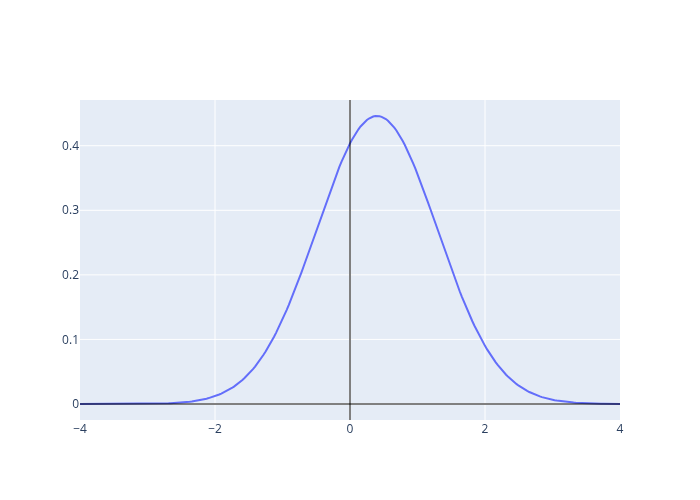

In [13]:
if __name__ == '__main__' and '__file__' not in globals():
  loc_given_sensor = _get_pxgy(pygx=sensor, px=location)
  loc = lambda x: loc_given_sensor(x, reading)
  _plot_function(loc, (-4, 4))

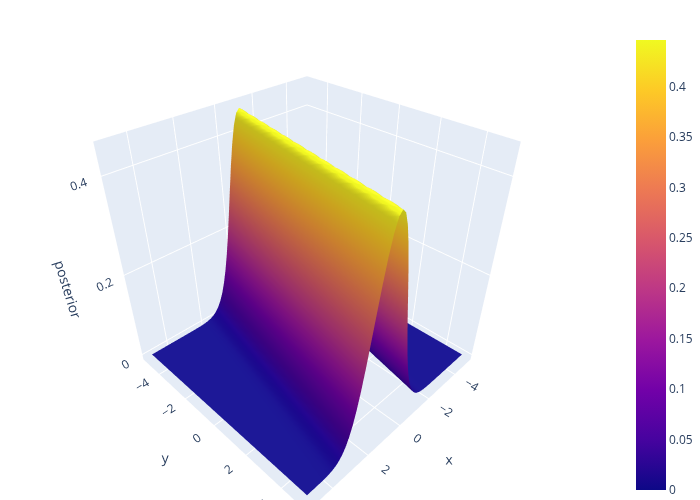

In [17]:
if __name__ == '__main__' and '__file__' not in globals():
  _plot_surface(loc_given_sensor)

In [21]:
if __name__ == '__main__' and '__file__' not in globals():
  mu = _mean(loc_given_sensor, [(-16, 16), (-16, 16)])
  pprint.pprint(_covariance(loc_given_sensor, [(-16, 16), (-16, 16)]))

array([[ 134.827,  546.133],
       [ 546.133, 2730.664]])
